In [59]:
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain
from langchain_core.runnables import RunnablePassthrough
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
load_dotenv()



os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")

os.environ["LANGCHAIN_TRACING_V2"] = "true"

os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT")


In [60]:
loader = PyPDFLoader("../1-DataIngestion/attention.pdf")
docs = loader.load()
docs

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-08-03T00:07:29+00:00', 'author': '', 'keywords': '', 'moddate': '2023-08-03T00:07:29+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../1-DataIngestion/attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGo

In [61]:
splitter =  RecursiveCharacterTextSplitter(chunk_size=300,chunk_overlap=30)
chunk_data = splitter.split_documents(docs)
chunk_data

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-08-03T00:07:29+00:00', 'author': '', 'keywords': '', 'moddate': '2023-08-03T00:07:29+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../1-DataIngestion/attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com'),
 Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-08-03T00:07:29+00:00', 'author': '', 'keywords': '', 'moddate': '2023-08-03T00:07:29+00:00', 'ptex.fullbanner': 'This is pd

In [62]:
embedder  =  HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [63]:
vectorDB = FAISS.from_documents(chunk_data,embedder)

In [64]:
prompt = ChatPromptTemplate.from_template("""
Answar the questions based on below context
"Context":{context},
"Question":{input}

""")

In [65]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen3-8B",
    task="text-generation",
    max_new_tokens=512
)

chat_llm = ChatHuggingFace(llm=llm)

In [82]:
document_chain = create_stuff_documents_chain(chat_llm ,prompt)

In [67]:
retriever = vectorDB.as_retriever()
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000002D5E4DC3CE0>, search_kwargs={})

In [68]:
rag_chain = create_retrieval_chain(retriever,document_chain)

In [80]:
response = rag_chain.invoke({"input":"Explain attention mechanism"})
for response in response["context"]:
    print(response.page_content)

,
in
my
opinion
.
<EOS>
<pad>
Figure 5: Many of the attention heads exhibit behaviour that seems related to the structure of the
sentence. We give two such examples above, from two different heads from the encoder self-attention
at layer 5 of 6. The heads clearly learned to perform different tasks.
3.2 Attention
An attention function can be described as mapping a query and a set of key-value pairs to an output,
where the query, keys, values, and output are all vectors. The output is computed as a weighted sum
3
constraint of sequential computation, however, remains.
Attention mechanisms have become an integral part of compelling sequence modeling and transduc-
tion models in various tasks, allowing modeling of dependencies without regard to their distance in
to averaging attention-weighted positions, an effect we counteract with Multi-Head Attention as
described in section 3.2.
Self-attention, sometimes called intra-attention is an attention mechanism relating different positions


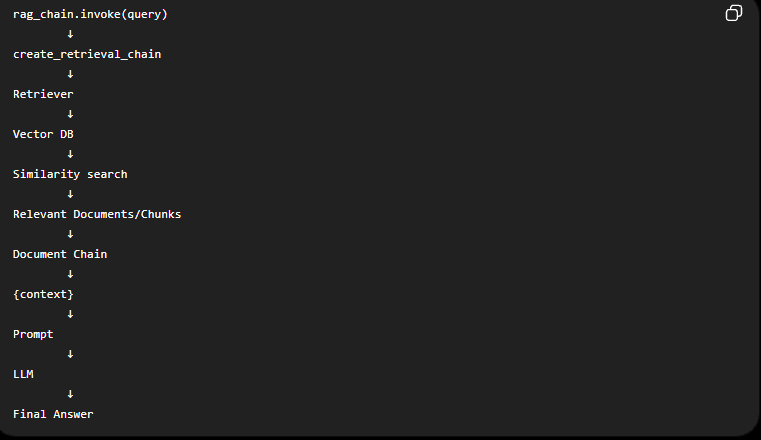

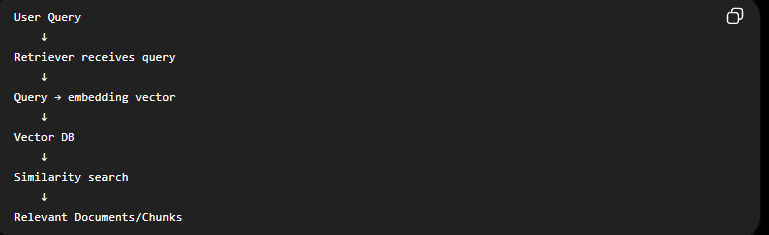

### After retrieve Relevant Documents/Chunks  , this Relevant Documents/Chunks  will be used by prompt for the context of the LLM model to give  the answer.
